# Exploring Clusters

This notebook explores the clusters that were formed by the K-Means Clustering in the notebook `module_1_clustering.ipynb`. Specifically, the goal is to determine the structure of the clusters across the real-estate, social and commercial dimension. 

## Load packages and Data

In [ ]:
#load packages
import pandas as pd 
import numpy as np
from sklearn.impute import KNNImputer
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer
import seaborn as sns

In [30]:
#load dataframes 
clusters = pd.read_csv("../../data/Module_1/cluster_assignments.csv", dtype={"plr_id": str})
features = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})
ms = pd.read_csv("../../data/Module 2/target_milieuschutz.csv", dtype={"plr_id": str})

#define id columns and feature columns
id_cols = ["plr_id", "plr_name", "bez"]
feat_cols = [c for c in features.columns if c not in id_cols]

#impute missing values: 
X = features[feat_cols].copy()

# impute feature columns
X_imp = pd.DataFrame(
    KNNImputer(n_neighbors=3).fit_transform(X),
    columns=feat_cols, index=features.index,
)

#concat dataframe
df_imp = pd.concat([features[id_cols], X_imp], axis=1)

print(df_imp.shape, "| remaining NaN in feature columns:",
      int(df_imp[feat_cols].isna().sum().sum()))
df_imp.head(3)

(527, 45) | remaining NaN in feature columns: 0


,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,01100101,Stülerstraße,01 - Mitte,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,...,0.001367,-0.000276,0.024083,0.002754,0.003153,-0.002800,0.001395,13.000000,0.118160,0.102663
1,01100102,Großer Tiergarten,01 - Mitte,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,...,0.003015,0.001063,0.028592,0.002506,0.004856,-0.000930,-0.000664,129.333333,0.228719,0.297506
2,01100103,Lützowstraße,01 - Mitte,23.0,1.356,1.863997,3541.826020,-0.440097,16.223680,0.455,...,0.001498,0.001101,0.032530,-0.001222,0.000177,-0.001019,0.000103,43.833333,0.323783,0.130135


In [31]:
#merge clusters 
df_merge1 = df_imp.merge(clusters, on="plr_id", how="left")
#check 
print(df_merge1.shape)

(527, 47)


In [32]:
#merge milieuschutz areas 
df = df_merge1.merge(ms, on = ['plr_id', 'plr_name', 'bez'], how = "left")
print(df.shape)
df.head(2)

(527, 49)


,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share,cluster_3k,cluster_4k,milieu_anteil,milieu_majoritaet
0,01100101,Stülerstraße,01 - Mitte,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,...,0.003153,-0.00280,0.001395,13.000000,0.118160,0.102663,2,1,0.0,0
1,01100102,Großer Tiergarten,01 - Mitte,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,...,0.004856,-0.00093,-0.000664,129.333333,0.228719,0.297506,2,1,0.0,0


In [33]:
#rename columns from german > english (ms = milieuschutz: protected area under § 172 BGB)
df.rename(columns={"milieu_anteil": "ms_portion", "milieu_majoritaet": "ms_binary"}, inplace = True)
#save 
df.to_csv("../../data/final_datasets/df_clusters_milieuschutz.csv", index=False)
df.head(2)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share,cluster_3k,cluster_4k,ms_portion,ms_binary
0,01100101,Stülerstraße,01 - Mitte,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,...,0.003153,-0.00280,0.001395,13.000000,0.118160,0.102663,2,1,0.0,0
1,01100102,Großer Tiergarten,01 - Mitte,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,...,0.004856,-0.00093,-0.000664,129.333333,0.228719,0.297506,2,1,0.0,0


## Gentrification Profiles

### Map

To get an overview of the geographic spread of the clusters across Berlin, let's look at them on a map.

In [34]:
url = ("https://gdi.berlin.de/services/wfs/lor_2021?service=WFS&version=2.0.0"
       "&request=GetFeature&typeNames=lor_2021:a_lor_plr_2021&outputFormat=application/json")
plr_geo = gpd.read_file(url)

# get plr-id's to strings with len 8
plr_geo["plr_id"] = plr_geo["plr_id"].astype(str).str.zfill(8)
df["plr_id_str"] = df["plr_id"].astype(str).str.zfill(8)

gdf = plr_geo.merge(df[["plr_id_str", "cluster_4k"]],
                    left_on="plr_id", right_on="plr_id_str", how="left")
print("matched:", gdf["cluster_4k"].notna().sum(), "von", len(gdf))

matched: 527 von 542


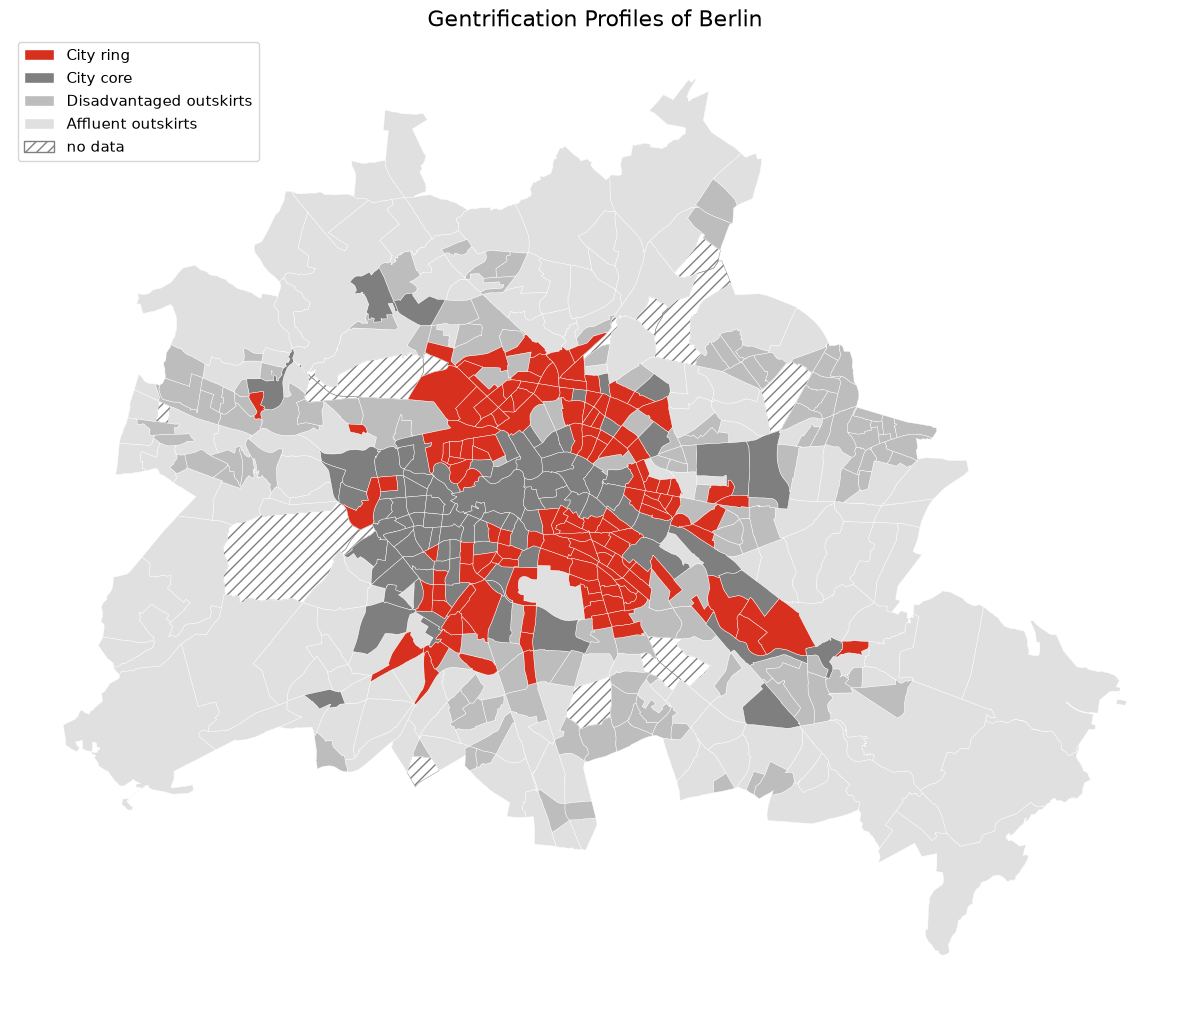

In [35]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 12))
k = 4

cluster_colors = {
    3: "#d7301f",   # City ring — kräftiges Rot-Orange (HERVORGEHOBEN, aktiv gentrifizierend)
    1: "#7f7f7f",   # City core — mittelgrau (Kontext)
    2: "#bdbdbd",   # Disadvantaged outskirts — helleres grau
    0: "#e0e0e0",   # Affluent outskirts — hellstes grau
}
cluster_labels = {
    1: "City core",
    3: "City ring",
    2: "Disadvantaged outskirts",
    0: "Affluent outskirts",
}

gdf[gdf["cluster_4k"].isna()].plot(
    ax=ax, color="none", edgecolor="grey", hatch="///", linewidth=0.3)

# Kontext-Cluster zuerst, dann City ring zuletzt (liegt oben)
for c in [0, 2, 1, 3]:
    gdf[gdf["cluster_4k"] == c].plot(
        ax=ax, color=cluster_colors[c], edgecolor="white", linewidth=0.3)

handles = [Patch(facecolor=cluster_colors[c], edgecolor="white", label=cluster_labels[c])
           for c in [3, 1, 2, 0]]   # City ring zuerst in der Legende
handles.append(Patch(facecolor="none", edgecolor="grey", hatch="///", label="no data"))
ax.legend(handles=handles, loc="upper left", fontsize=11, frameon=True)

ax.set_title(f"Gentrification Profiles of Berlin", fontsize=16)
ax.axis("off"); plt.tight_layout(); 
fig.savefig("../../plots/gentrification_profiles/cluster_map.png", dpi=300, bbox_inches="tight")
plt.show()

In order to determine whether the clusters can actually be described as gentrification phases/profiles, we need to take a look at what separates them and what characterizes each cluster. 

### Trend vs. Level:

In [44]:
def is_dynamic(c):
    return any(t in c for t in ["_trend", "_slope", "_change"])

for label, cols in [("LEVEL", [c for c in feat_cols if not is_dynamic(c)]),
                    ("DYNAMIC", [c for c in feat_cols if is_dynamic(c)])]:
    print(f"\n{'='*60}\n{label}\n{'='*60}")
    print(df.groupby("cluster_4k")[cols].mean().T.round(2).to_string())


LEVEL
cluster_4k                                    0        1       2        3
re_miete_niveau                           14.00    20.23   10.76    16.43
re_leerstandsquote                         2.21     2.33    1.80     2.03
re_brw_niveau                            772.06  3309.71  678.28  2436.18
re_dichte_all                              3.21    13.05    1.12    12.13
soc_young_to_middle_adult_share_2025       0.30     0.43    0.38     0.47
soc_average_household_size_2024            1.96     1.72    1.82     1.67
soc_internal_migration_volume_rate_2025    0.14     0.19    0.14     0.17
soc_internal_net_migration_rate_2025       0.01     0.00    0.01    -0.01
soc_transfer_benefit_share_2024            0.06     0.08    0.14     0.12
soc_single_parent_household_share_2024     0.05     0.04    0.06     0.04
com_median_age_level_2026                  7.79     6.96    5.02     5.84
com_share_solo_level_2026                  0.68     0.59    0.80     0.74
com_share_10plus_level_2026    

### Dimensions within profiles

First, let's look at a few variables that seem interesting based on prior knowledge of the data. 

42 Features


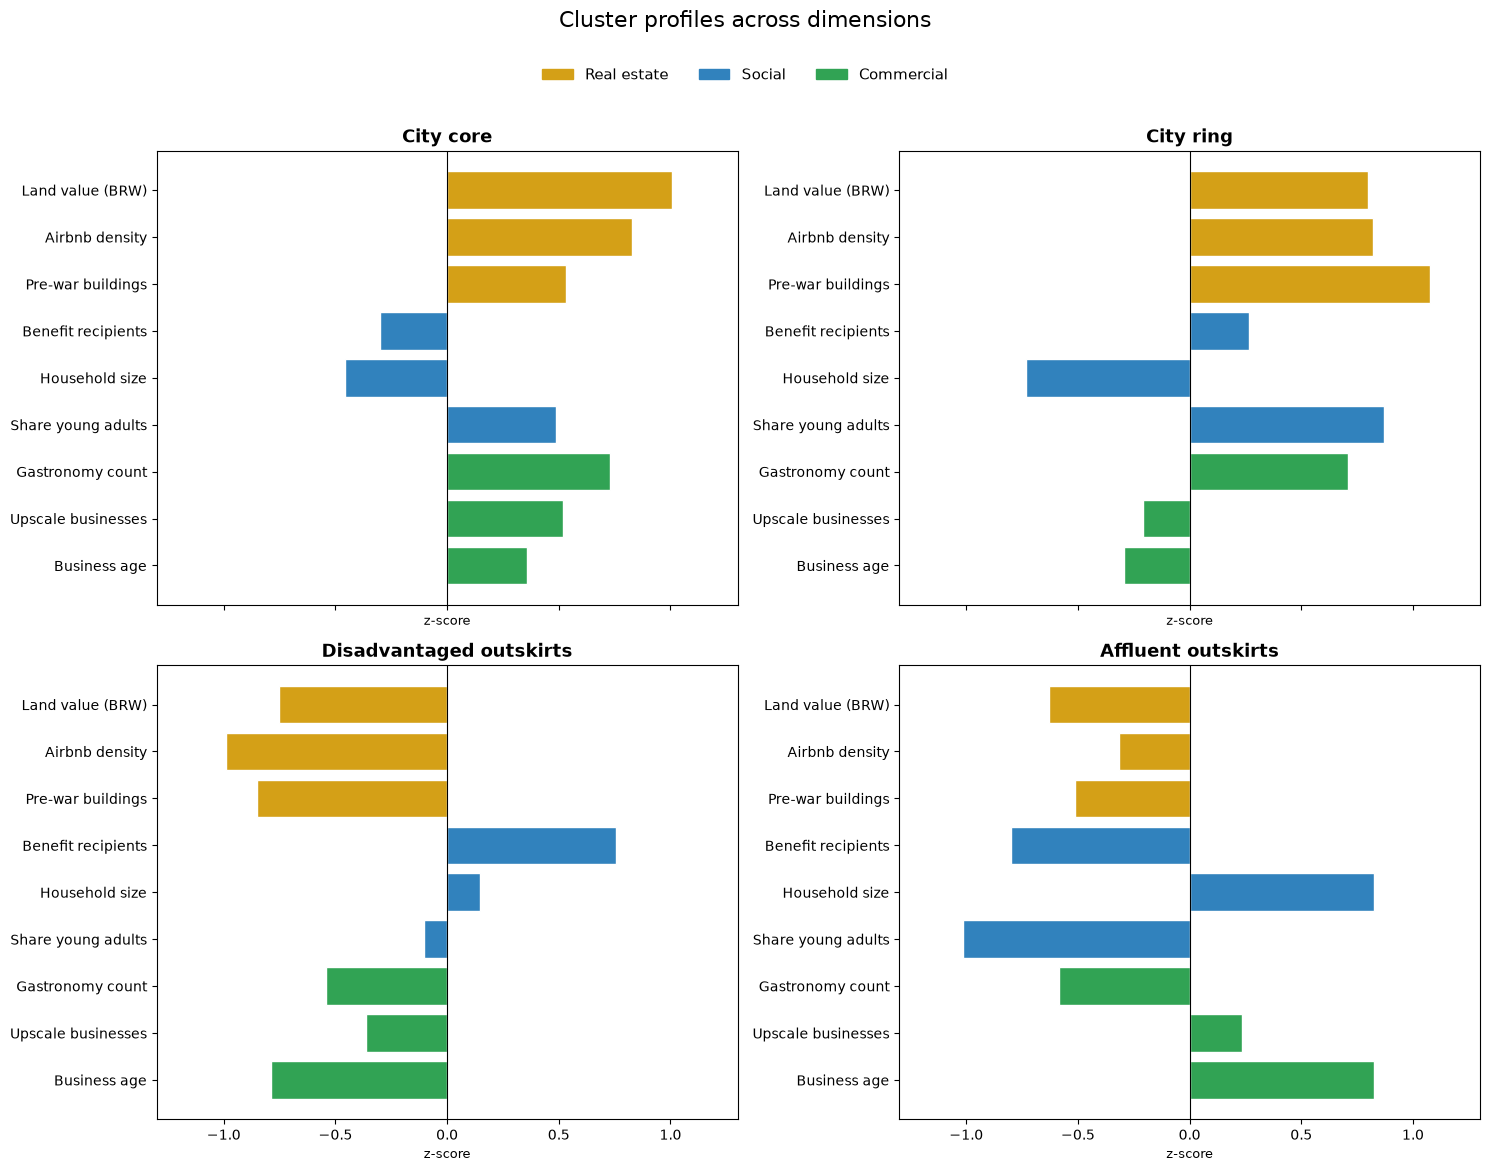

In [38]:
#prepare data
id_cols = ["plr_id", "plr_name", "bez"]
non_features = id_cols + ["cluster_3k", "cluster_4k", "ms_portion", "ms_binary", "plr_id_str"]
feat_cols = [c for c in df.columns if c not in non_features]
print(len(feat_cols), "Features") 

X = df[feat_cols]

X_scaled = pd.DataFrame(
    PowerTransformer("yeo-johnson", standardize=True).fit_transform(X),
    columns=feat_cols, index=X_imp.index,
)


Xs = X_scaled.copy()
Xs["cluster_4k"] = df["cluster_4k"].values


chosen = ["re_brw_niveau", "re_dichte_all", "re_altbau_share", #land value, airbnb density, old building share
          "soc_transfer_benefit_share_2024", "soc_average_household_size_2024", "soc_young_to_middle_adult_share_2025", #transfer benefits, average household size, 
          "com_n_gastro", "com_upscale_share_level_2026", "com_median_age_level_2026"] #gastro establishments, upscale gastro, median age of businesses

axis_labels = {
    "re_brw_niveau": "Land value (BRW)",
    "re_dichte_all": "Airbnb density",
    "re_altbau_share": "Pre-war buildings",
    "soc_transfer_benefit_share_2024": "Benefit recipients",
    "soc_average_household_size_2024": "Household size",
    "soc_young_to_middle_adult_share_2025": "Share young adults",
    "com_n_gastro": "Gastronomy count",
    "com_upscale_share_level_2026": "Upscale businesses",
    "com_median_age_level_2026": "Business age",
}

# re_ = Gold, soc_ = Blau, com_ = Grün
dim_color = {"re_": "#d4a017", "soc_": "#3182bd", "com_": "#31a354"}
bar_colors = [next(dim_color[p] for p in dim_color if v.startswith(p)) for v in chosen]

z = Xs.groupby("cluster_4k")[chosen].mean()

labels = {1: "City core", 3: "City ring",
          2: "Disadvantaged outskirts", 0: "Affluent outskirts"}
order = [1, 3, 2, 0]

fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=True)
ypos = np.arange(len(chosen))
for ax, c in zip(axes.flat, order):
    ax.barh(ypos, z.loc[c, chosen].values, color=bar_colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(ypos); ax.set_yticklabels([axis_labels[v] for v in chosen], fontsize=10)
    ax.invert_yaxis()
    ax.set_title(labels[c], fontsize=13, fontweight="bold")
    ax.set_xlabel("z-score", fontsize=9); ax.set_xlim(-1.3, 1.3)

handles = [Patch(color="#d4a017", label="Real estate"),
           Patch(color="#3182bd", label="Social"),
           Patch(color="#31a354", label="Commercial")]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.suptitle("Cluster profiles across dimensions", fontsize=16, y=1.06)
plt.tight_layout()
fig.savefig("../../plots/gentrification_profiles/cluster_profiles.png", dpi=300, bbox_inches="tight")
plt.show()

The four profiles reveal a clear gentrification gradient by state:

- **City core:** is defined by its real-estate and commercial strength: the highest land values, Airbnb density, gastronomy counts, and upscale business share, paired with small households, below-average benefit dependency, and an above-average share of young adults. This is the mature, high-value, already-upgraded inner city.
- **City ring:** shares the core's density and gastronomy but is distinguished by the highest share of pre-war buildings, the youngest business stock, the smallest households, and the largest share of young adults, alongside moderately higher benefit dependency. This is the actively transforming inner-city milieu — dense, characterful, young, and still socially mixed.
- **Disadvantaged outskirts** show the mirror image: the highest benefit dependency, low land values, and the youngest, least upscale commercial structure, with a below-average share of young adults. These are the socially strained peripheral estates.
- **Affluent outskirts:** marked by the largest households, the oldest and most established businesses, the lowest benefit dependency, and the smallest share of young adults — a settled, family-oriented residential type that is not undergoing gentrification.

Across all four profiles, the differentiation is driven almost entirely by level variables (current state) rather than dynamic ones, supporting an interpretation of the clusters as gentrification profiles — distinct area types at different stages of the process — rather than temporal phases.

### Most discriminating variables:

So far, the variable selection has been interest-driven. Let's look at a data-driven selection of variables that seperate the clusters.

In [ ]:
# show the 20 most discriminating variables 
means_by_cluster = Xs.groupby("cluster_4k")[feat_cols].apply(
    lambda g: g.mean())   

Xs = X_scaled.copy(); Xs["cluster_4k"] = df["cluster_4k"].values
spread = Xs.groupby("cluster_4k")[feat_cols].mean().var().sort_values(ascending=False)
print(spread.head(20))

re_brw_niveau                                  0.857296
re_miete_niveau                                0.805934
re_altbau_share                                0.805855
re_dichte_all                                  0.805692
soc_young_to_middle_adult_share_2025           0.671929
com_share_solo_level_2026                      0.652160
re_brw_trend                                   0.607197
com_n_gastro                                   0.550424
soc_single_parent_household_share_2024         0.541097
com_exit_rate_level_2026                       0.515219
com_median_age_level_2026                      0.504414
soc_average_household_size_2024                0.479698
soc_transfer_benefit_share_2024                0.454840
com_entry_rate_level_2026                      0.375490
com_tourism_share_level_2026                   0.338258
soc_internal_migration_volume_rate_2025        0.329522
soc_transfer_benefit_share_change_2020_2024    0.326458
re_miete_trend                                 0

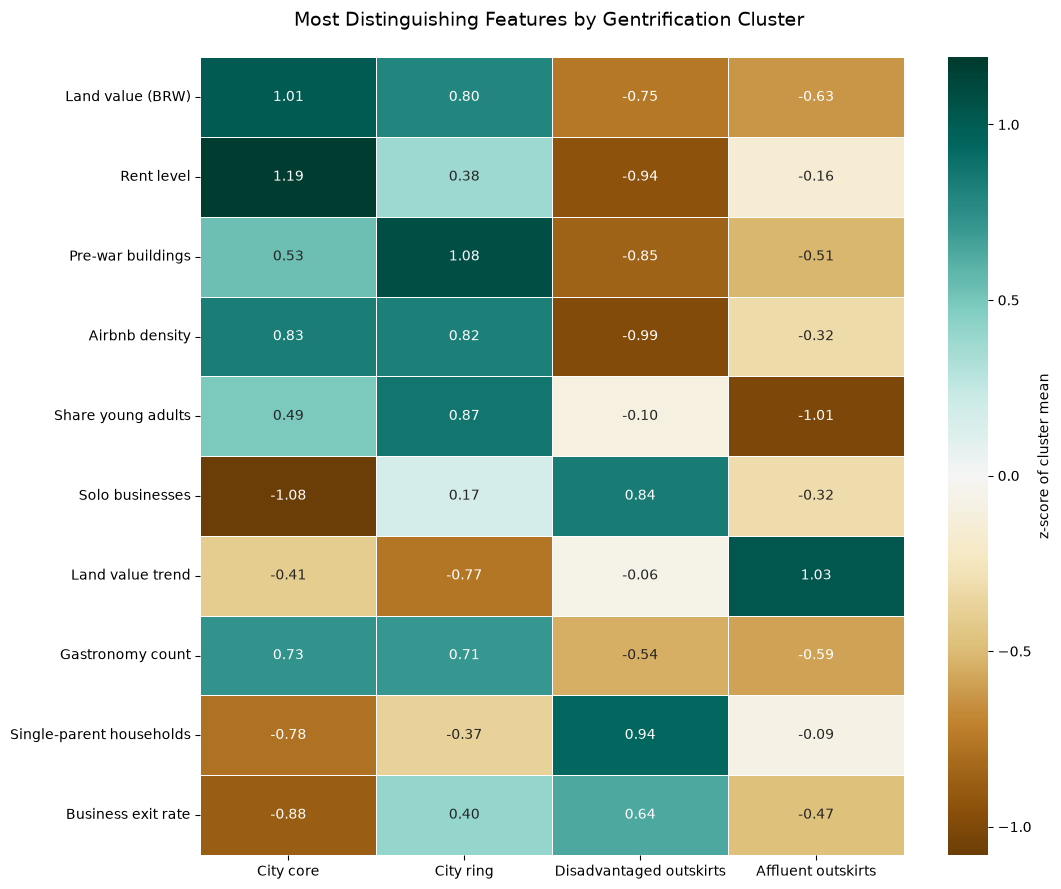

In [69]:
# Top 10 (based on spread: largest variance between cluster means)
spread = Xs.groupby("cluster_4k")[feat_cols].mean().var().sort_values(ascending=False)
chosen = spread.head(10).index.tolist()

axis_labels = {
    "re_brw_niveau": "Land value (BRW)",
    "re_miete_niveau": "Rent level",
    "re_dichte_all": "Airbnb density",
    "re_altbau_share": "Pre-war buildings",
    "re_neubau_share": "New-build share",
    "re_brw_trend": "Land value trend",
    "re_miete_trend": "Rent trend",
    "soc_young_to_middle_adult_share_2025": "Share young adults",
    "soc_single_person_hh_share_2024": "Single-person households",
    "soc_single_parent_household_share_2024": "Single-parent households",
    "soc_average_household_size_2024": "Household size",
    "soc_transfer_benefit_share_2024": "Benefit recipients",
    "com_share_solo_level_2026": "Solo businesses",
    "com_exit_rate_level_2026": "Business exit rate",
    "com_entry_rate_level_2026": "Business entry rate",
    "com_n_gastro": "Gastronomy count",
    "com_upscale_share_level_2026": "Upscale businesses",
    "com_median_age_level_2026": "Business age",
}

labels = {1:"City core", 3:"City ring", 2:"Disadvantaged outskirts", 0:"Affluent outskirts"}
order = [1, 3, 2, 0]

zt = Xs.groupby("cluster_4k")[chosen].mean().reindex(order).T
zt.columns = [labels[c] for c in order]
zt.index = [axis_labels.get(v, v) for v in chosen]      # <- lesbare Labels

plt.figure(figsize=(11, 9))
sns.heatmap(zt, cmap="BrBG", center=0, annot=True, fmt=".2f",
            linewidths=0.5, cbar_kws={"label": "z-score of cluster mean"})
plt.title("Most Distinguishing Features by Gentrification Cluster \n", fontsize = 14)
plt.tight_layout(); 
fig.savefig("../../plots/gentrification_profiles/distinguishing_features.png", dpi=300, bbox_inches="tight")
plt.show()

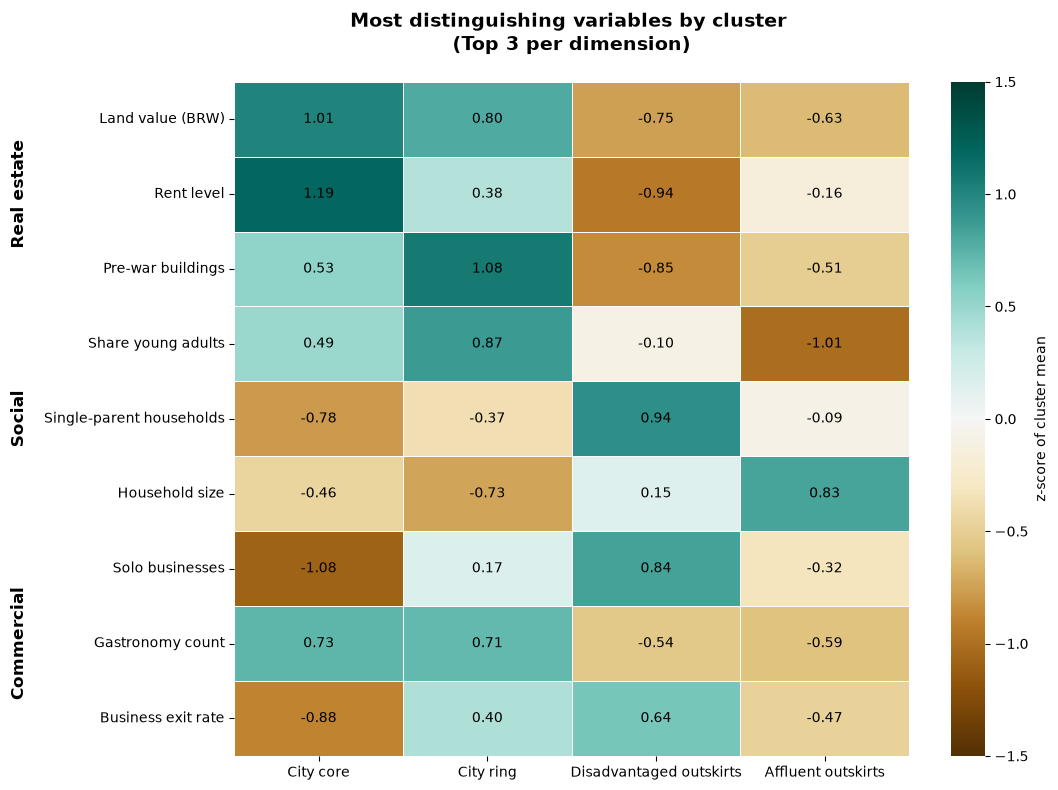

In [70]:
import seaborn as sns, matplotlib.pyplot as plt

spread = Xs.groupby("cluster_4k")[feat_cols].mean().var()
chosen = []
for pre in ["re_", "soc_", "com_"]:
    dim = spread[[c for c in feat_cols if c.startswith(pre)]].sort_values(ascending=False)
    chosen += dim.head(3).index.tolist()

axis_labels = {
    "re_brw_niveau":"Land value (BRW)", "re_dichte_all":"Airbnb density",
    "re_miete_niveau":"Rent level", "re_altbau_share":"Pre-war buildings",
    "soc_single_person_hh_share_2024":"Single-person households",
    "soc_young_to_middle_adult_share_2025":"Share young adults",
    "soc_single_parent_household_share_2024":"Single-parent households",
    "soc_average_household_size_2024":"Household size",
    "com_share_solo_level_2026":"Solo businesses",
    "com_exit_rate_level_2026":"Business exit rate", "com_n_gastro":"Gastronomy count",
}
labels = {1:"City core", 3:"City ring", 2:"Disadvantaged outskirts", 0:"Affluent outskirts"}
order = [1, 3, 2, 0]

zt = Xs.groupby("cluster_4k")[chosen].mean().reindex(order).T
zt.columns = [labels[c] for c in order]
zt.index = [axis_labels.get(v, v) for v in chosen]

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(zt, cmap="BrBG", center=0, annot=True, fmt=".2f",
            vmin=-1.5, vmax=1.5, linewidths=0.5, linecolor="white",
            annot_kws={"color":"black","fontsize":10},
            cbar_kws={"label":"z-score of cluster mean"}, ax=ax)


# Dimensionsnamen links neben den Blöcken (Blockmitte: 1.5, 4.5, 7.5)
dim_names = [("Real estate", 1.5), ("Social", 4.5), ("Commercial", 7.5)]
for name, ypos in dim_names:
    ax.text(-0.32, ypos, name, transform=ax.get_yaxis_transform(),
            rotation=90, va="center", ha="center",
            fontsize=12, fontweight="bold")

plt.title("Most distinguishing variables by cluster \n(Top 3 per dimension)\n", fontsize = 14, fontweight="bold")
plt.tight_layout(); 
fig.savefig("../../plots/gentrification_profiles/distinguishing_features_perdim.png", dpi=300, bbox_inches="tight")
plt.show()

## Milieuschutz areas

The next step 

## Add-on: Clusters based on change variables only

Earlier, it became clear that the trend variables did not contribute much to the clustering. This is an exploration whether clustering on the trend variables alone adds any value.

In [14]:
id_cols = ["plr_id", "plr_name", "bez"]
non_features = id_cols + ["cluster_3k", "cluster_4k", "ms_portion", "ms_binary", "plr_id_str"]
feat_cols = [c for c in df.columns if c not in non_features]
print(len(feat_cols), "Features") 

X = df[feat_cols]

X_scaled = pd.DataFrame(
    PowerTransformer("yeo-johnson", standardize=True).fit_transform(X),
    columns=feat_cols, index=X_imp.index,
)

X_scaled.head(3)

42 Features


,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,soc_young_to_middle_adult_share_change_2021_2025,soc_single_person_hh_share_change_2021_2024,soc_average_household_size_2024,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,1.707607,1.345248,1.062483,1.401119,-0.514159,0.938569,0.789265,-0.423212,-0.854709,-1.183481,...,-0.059062,-0.227172,1.531979,0.952109,0.959637,-1.143363,-0.728138,-0.314274,-0.225292,0.638800
1,1.219387,0.033646,1.781115,1.306092,-1.096115,1.599031,0.985896,-0.282827,-1.223596,-0.004727,...,0.407217,0.680906,1.898433,0.860206,1.724478,-0.424651,-1.854356,1.880504,0.381165,1.777773
2,1.767611,0.419433,0.074113,1.329091,-1.175228,1.284139,0.736851,0.555171,-0.191582,-0.444817,...,-0.021163,0.706418,2.197820,-0.451547,-0.201956,-0.461120,-1.439860,0.830252,0.755869,0.929094


21 change-Variablen


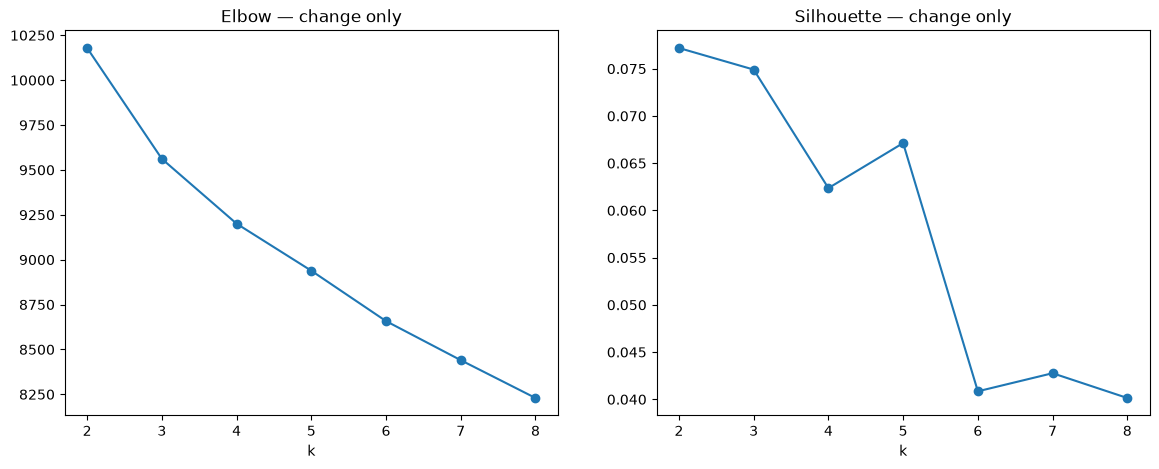

k=2: silhouette = 0.077
k=3: silhouette = 0.075
k=4: silhouette = 0.062
k=5: silhouette = 0.067
k=6: silhouette = 0.041
k=7: silhouette = 0.043
k=8: silhouette = 0.040


In [69]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

change_cols = [c for c in feat_cols if any(t in c for t in ["_trend","_slope","_change"])]
X_change = X_scaled[change_cols]     # schon standardisiert (Option A)
print(f"{len(change_cols)} change-Variablen")

# Elbow + Silhouette über k
Ks = range(2, 9)
wcss, sils = [], []
for k in Ks:
    km = KMeans(k, n_init=10, random_state=0).fit(X_change)
    wcss.append(km.inertia_)
    sils.append(silhouette_score(X_change, km.labels_))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14,5))
a1.plot(Ks, wcss, "o-"); a1.set_title("Elbow — change only"); a1.set_xlabel("k")
a2.plot(Ks, sils, "o-"); a2.set_title("Silhouette — change only"); a2.set_xlabel("k")
plt.show()

for k, s in zip(Ks, sils):
    print(f"k={k}: silhouette = {s:.3f}")

The silhouette scores are alarmingly low and the elbow plot almost looks like a straight line. Thus, even when clustering on the dynamic variables alone, the differences are not enough for a solid clustering base. 